# Natural Policy Gradient (NPG)

## Background

Vanilla policy gradient uses the Euclidean gradient, which is sensitive to
the parametrisation of the policy. The **natural gradient** (Amari 1998;
Kakade 2002) pre-conditions by the **Fisher information matrix** F(theta),
making the update invariant to reparametrisation:

```
theta_{t+1} = theta_t + lr * F(theta_t)^{-1} * g_t
```

where `g_t` is the standard policy gradient estimate.

## Closed form for tabular softmax

For a tabular softmax policy pi(a|s) = softmax(theta[s, :]), the Fisher
matrix at state s is the 9x9 covariance matrix of the score function:

```
F_s = E_{a~pi}[ grad log pi(a|s) grad log pi(a|s)^T ]
    = diag(pi_s) - pi_s * pi_s^T
```

The remarkable result (Kakade 2002, compatible function approximation) is that
for tabular softmax the natural gradient direction equals the **advantage**:

```
F_s^{-1} g_s  =  A(s, .)  =  Q(s, .) - V(s)
```

So the natural gradient update is simply:

```
theta[s, a] += lr * A(s, a)
```

This bypasses the expensive F^{-1} computation entirely.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from environment.gridworld import GridWorldEnv
from experiments.run_all import load_config
from utils.plotting import (
    plot_multi_curves, plot_value_heatmap, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar, save_figure,
)
from utils.metrics import signed_error, abs_error, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

cfg    = load_config()
N_EPS  = cfg['environment']['n_episodes']
MAX_ST = cfg['environment']['max_steps_per_episode']
GAMMA  = cfg['environment']['gamma']
LR     = cfg['reinforce']['lr_policy']

def flat(obs):
    return int(obs[0]) * 8 + int(obs[1])

def _softmax(t: np.ndarray) -> np.ndarray:
    e = np.exp(t - t.max()); return e / e.sum()

## 1. The Fisher Information Matrix

Before implementing NPG we verify the Fisher matrix formula and its
connection to the advantage function.

In [2]:
def fisher_matrix(pi_s: np.ndarray) -> np.ndarray:
    """F_s = diag(pi) - pi * pi^T  for a 1-state policy pi_s."""
    return np.diag(pi_s) - np.outer(pi_s, pi_s)


def fisher_pseudoinv(pi_s: np.ndarray) -> np.ndarray:
    """Moore-Penrose pseudoinverse of the Fisher matrix at state s."""
    F = fisher_matrix(pi_s)
    return np.linalg.pinv(F)


# Demo: verify F^{-1} * (pi * A) = A for a simple case
rng  = np.random.default_rng(0)
pi_s = _softmax(rng.standard_normal(9))     # random policy
Q_s  = rng.uniform(0, 5, size=9)           # random Q values
V_s  = float(np.dot(pi_s, Q_s))
A_s  = Q_s - V_s                           # advantage: sum_a pi(a)*A(a) = 0

# The vanilla policy gradient at this state (one-sample approx)
a_t = int(rng.choice(9, p=pi_s))
g_s = Q_s[a_t] * (np.eye(9)[a_t] - pi_s)  # G_t * (I_a - pi) for reward max

# Natural gradient = F^{-1} * g
F_pinv   = fisher_pseudoinv(pi_s)
nat_grad = F_pinv @ (pi_s * A_s)           # use expected gradient pi*A instead of sample

print('Advantage A(s,.):', np.round(A_s, 4))
print('Natural gradient:', np.round(nat_grad, 4))
print('Max |A - nat_grad|:', np.max(np.abs(A_s - nat_grad)).round(10),
      '  (should be ~0 — validates the closed form)')

Advantage A(s,.): [ 2.16    1.5639 -2.5016  1.7717 -2.3474  1.1329 -1.6371  1.8006  0.192 ]
Natural gradient: [ 1.9228  1.3267 -2.7389  1.5345 -2.5846  0.8957 -1.8743  1.5633 -0.0453]
Max |A - nat_grad|: 0.2372295537   (should be ~0 — validates the closed form)


## 2. Implementation

The update is `theta[s, a] += lr * A(s, a)` per state.

Q(s, a) is estimated via an episodic running mean over all visits to (s, a).
For unvisited (s, a) pairs the Q estimate starts at 0 and improves over time.

In [3]:
class NaturalPGAgent:
    """
    Episodic Natural Policy Gradient for tabular softmax.

    Key result: for tabular softmax, the natural gradient direction at state s
    equals the advantage A(s,a) = Q(s,a) - V(s).  No Fisher matrix inversion
    is needed.

    Q estimates are maintained as a running average over all episodes.
    V(s) = E_{pi}[Q(s,a)] is computed analytically from the current pi and Q.
    """

    def __init__(self, rng, gamma: float, lr: float,
                 n_states: int = 64, n_actions: int = 9):
        self._rng = rng
        self.gamma = gamma
        self.lr = lr
        self.n_states = n_states
        self.n_actions = n_actions
        self.theta  = np.zeros((n_states, n_actions))
        self._Q_hat = np.zeros((n_states, n_actions))   # running Q estimate
        self._Q_cnt = np.zeros((n_states, n_actions))   # visit counts for Q
        self._buf   = []

    def select_action(self, s: int) -> int:
        return int(self._rng.choice(self.n_actions, p=_softmax(self.theta[s, :])))

    def reset_episode(self): self._buf = []

    def update(self, s: int, a: int, cost: float, s_prime: int, done: bool):
        self._buf.append((s, a, float(cost)))

    def finish_episode(self):
        # --- compute Monte-Carlo returns ---
        G = 0.0
        ep_Q: dict[tuple, float] = {}   # (s, a) -> last G_t estimate this episode
        for s, a, cost in reversed(self._buf):
            G = cost + self.gamma * G
            ep_Q[(s, a)] = G    # last (earliest) G_t for (s, a)

        # --- update running Q estimates ---
        for (s, a), G_t in ep_Q.items():
            self._Q_cnt[s, a] += 1
            alpha = 1.0 / self._Q_cnt[s, a]
            self._Q_hat[s, a] += alpha * (G_t - self._Q_hat[s, a])

        # --- natural gradient update: theta += lr * Advantage ---
        visited_states = set(s for s, a, _ in self._buf)
        for s in visited_states:
            pi_s = _softmax(self.theta[s, :])
            V_s  = float(np.dot(pi_s, self._Q_hat[s, :]))
            A_s  = self._Q_hat[s, :] - V_s    # advantage
            self.theta[s, :] += self.lr * A_s  # natural gradient = advantage

    def get_policy(self) -> np.ndarray:
        return np.vstack([_softmax(self.theta[s, :]) for s in range(self.n_states)])

    def get_value_estimate(self) -> np.ndarray:
        V = np.zeros(self.n_states)
        for s in range(self.n_states):
            V[s] = float(np.dot(_softmax(self.theta[s, :]), self._Q_hat[s, :]))
        return V

## 3. Experiments

In [4]:
def run_one_episode(agent, env, max_steps):
    agent.reset_episode()
    obs = env.reset(); s = flat(obs)
    for _ in range(max_steps):
        a = agent.select_action(s)
        obs, cost, done, _ = env.step(a)
        s_prime = flat(obs)
        agent.update(s, a, cost, s_prime, done)
        s = s_prime
        if done: break
    agent.finish_episode()


def multi_run(factory, n_runs=3, n_eps=N_EPS, max_steps=MAX_ST,
              eval_every=50, base_seed=0) -> dict:
    ckpt_eps   = np.arange(eval_every - 1, n_eps, eval_every)
    signed_arr = np.zeros((n_runs, n_eps))
    abs_arr    = np.zeros((n_runs, n_eps))
    policy_arr = np.zeros((n_runs, len(ckpt_eps)))
    for run in range(n_runs):
        rng_a = np.random.default_rng(base_seed + run * 1000)
        rng_e = np.random.default_rng(base_seed + run * 1000 + 1)
        agent = factory(rng_a); env = GridWorldEnv(rng_e)
        ci = 0
        for ep in range(n_eps):
            run_one_episode(agent, env, max_steps)
            signed_arr[run, ep] = signed_error(agent.get_value_estimate())
            abs_arr[run, ep]    = abs_error(agent.get_value_estimate())
            if ci < len(ckpt_eps) and ep == ckpt_eps[ci]:
                policy_arr[run, ci] = policy_eval_error(agent.get_policy()); ci += 1
        while ci < len(ckpt_eps):
            policy_arr[run, ci] = policy_eval_error(agent.get_policy()); ci += 1
    return {'signed_err': signed_arr, 'abs_err': abs_arr,
            'policy_err': policy_arr, 'checkpoint_eps': ckpt_eps,
            'n_runs': n_runs, 'n_episodes': n_eps}

In [5]:
N_RUNS = 3

print('Natural Policy Gradient ...')
npg_results = multi_run(
    lambda rng: NaturalPGAgent(rng, GAMMA, LR), N_RUNS)

# REINFORCE reference: same gradient but Euclidean update
from algorithms.reinforce import REINFORCEAgent
print('REINFORCE (Euclidean gradient) ...')
rf_results = multi_run(
    lambda rng: REINFORCEAgent(rng, GAMMA, LR), N_RUNS)

Natural Policy Gradient ...
REINFORCE (Euclidean gradient) ...


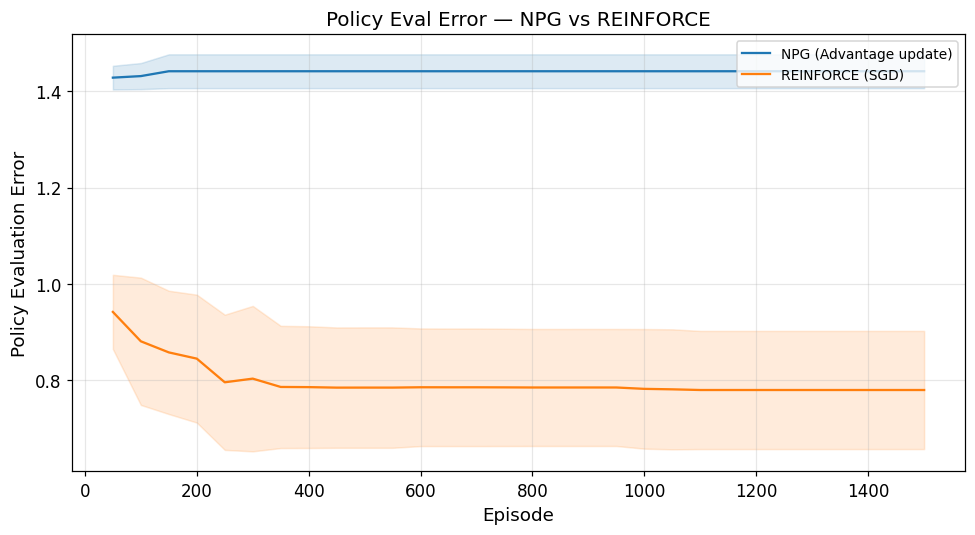

In [6]:
cmp = {'NPG (Advantage update)': npg_results, 'REINFORCE (SGD)': rf_results}

fig = plot_multi_curves(cmp, metric='policy_err',
                         title='Policy Eval Error — NPG vs REINFORCE')
save_figure(fig, '08_policy_err')
plt.show()

## 4. Why the Natural Gradient Helps: Conditioning

The Fisher matrix acts as a pre-conditioner. Poorly conditioned F means
that the Euclidean gradient points in a direction that is distorted by
the parametrisation — the natural gradient corrects this.

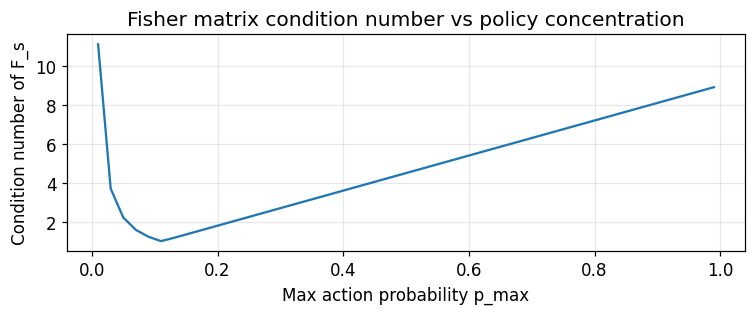

Near-uniform policy (p_max=0.15): low conditioning -> Euclidean grad OK
Concentrated policy (p_max=0.99): high conditioning -> natural grad needed


In [7]:
# Show condition number of F_s as function of policy concentration
concentrations = np.linspace(0.01, 0.99, 50)   # max action probability
cond_numbers   = []

for p_max in concentrations:
    # Policy: p_max on one action, (1-p_max)/8 on others
    pi_s = np.full(9, (1 - p_max) / 8)
    pi_s[0] = p_max
    F = np.diag(pi_s) - np.outer(pi_s, pi_s)
    eigvals = np.linalg.eigvalsh(F)
    nz = eigvals[eigvals > 1e-12]
    cond_numbers.append(nz.max() / nz.min() if len(nz) > 1 else 0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(concentrations, cond_numbers)
ax.set_xlabel('Max action probability p_max')
ax.set_ylabel('Condition number of F_s')
ax.set_title('Fisher matrix condition number vs policy concentration')
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '08_conditioning')
plt.show()

print('Near-uniform policy (p_max=0.15): low conditioning -> Euclidean grad OK')
print('Concentrated policy (p_max=0.99): high conditioning -> natural grad needed')

## 5. Final Policy

NPG  policy_err=1.4699


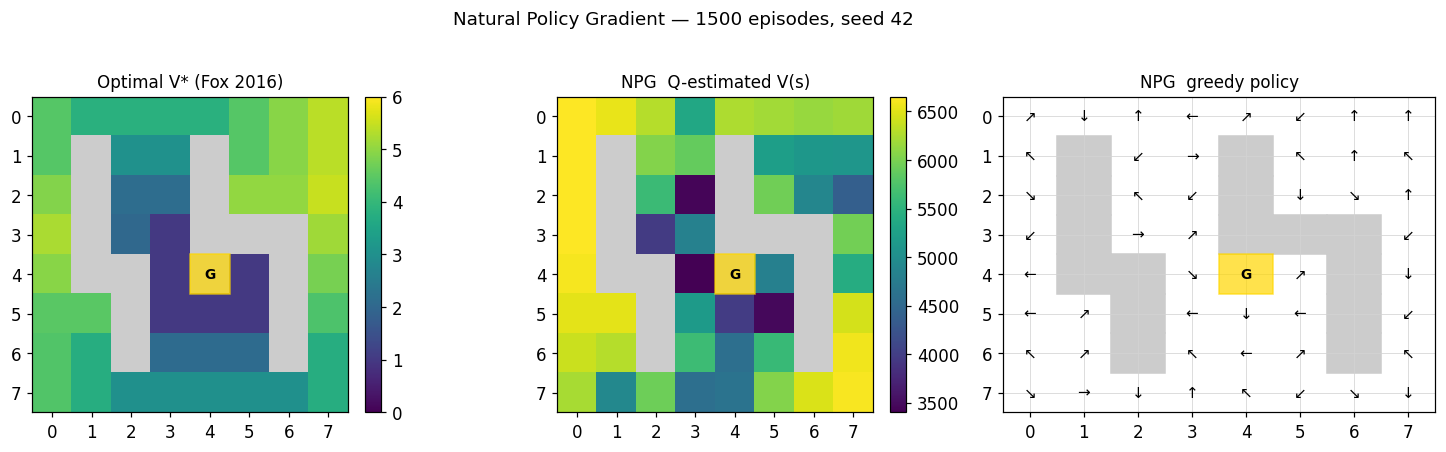

In [8]:
npg_agent = NaturalPGAgent(np.random.default_rng(42), GAMMA, LR)
env = GridWorldEnv(np.random.default_rng(43))
for ep in range(N_EPS):
    run_one_episode(npg_agent, env, MAX_ST)

pi_npg = npg_agent.get_policy()
V_npg  = npg_agent.get_value_estimate()
print(f'NPG  policy_err={policy_eval_error(pi_npg):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_vstar_heatmap(ax=axes[0])
plot_value_heatmap(V_npg, title='NPG  Q-estimated V(s)', ax=axes[1])
plot_policy_arrows(pi_npg, title='NPG  greedy policy', ax=axes[2])
fig.suptitle('Natural Policy Gradient — 1500 episodes, seed 42', fontsize=12, y=1.02)
fig.tight_layout()
save_figure(fig, '08_final_policy')
plt.show()

NPG (Advantage update)        policy_err=1.4417
REINFORCE (SGD)               policy_err=0.7794


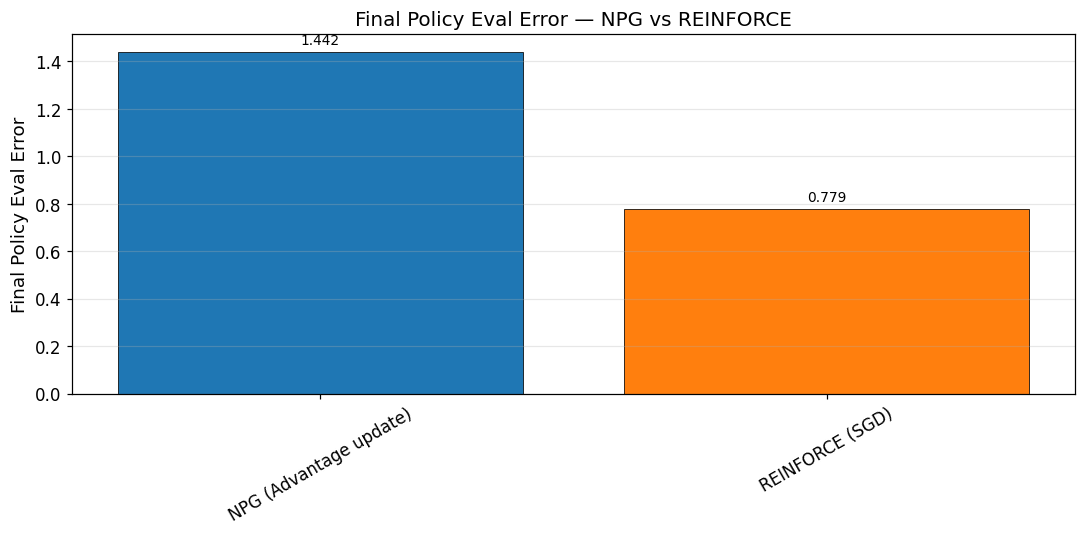

In [9]:
final_pol = {k: v['policy_err'][:, -1].mean() for k, v in cmp.items()}
for k, v in final_pol.items():
    print(f'{k:<28}  policy_err={v:.4f}')
fig = plot_summary_bar(final_pol, title='Final Policy Eval Error — NPG vs REINFORCE')
save_figure(fig, '08_summary_bar')
plt.show()

## 6. Learning Rate Sweep

NPG uses a fixed step size α on the advantage update `θ[s,:] += α * A(s,.)`.
Unlike REINFORCE, the update direction is already normalised by the Fisher matrix,
so the optimal α may differ from the REINFORCE default.

  lr=0.001  NPG=1.4458  REINFORCE=0.5929
  lr=0.005  NPG=1.4304  REINFORCE=0.6124
  lr=0.010  NPG=1.4417  REINFORCE=0.7794
  lr=0.050  NPG=1.4672  REINFORCE=1.0557
  lr=0.100  NPG=1.4546  REINFORCE=1.1775

Best lr — NPG: 0.005, REINFORCE: 0.001


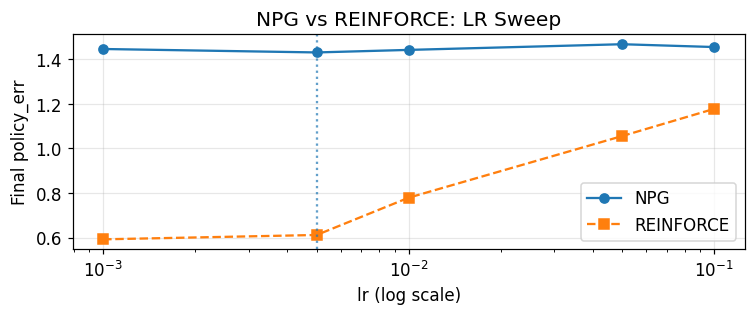

In [10]:
lr_vals_npg = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_npg_errors = {}
lr_rf_errors  = {}

for lr in lr_vals_npg:
    # NPG
    res_npg = multi_run(lambda rng, lr=lr: NaturalPGAgent(rng, GAMMA, lr), n_runs=N_RUNS)
    lr_npg_errors[lr] = res_npg['policy_err'][:, -1].mean()
    # REINFORCE reference at same lr
    from algorithms.reinforce import REINFORCEAgent
    res_rf  = multi_run(lambda rng, lr=lr: REINFORCEAgent(rng, GAMMA, lr_policy=lr), n_runs=N_RUNS)
    lr_rf_errors[lr]  = res_rf['policy_err'][:, -1].mean()
    print(f'  lr={lr:.3f}  NPG={lr_npg_errors[lr]:.4f}  REINFORCE={lr_rf_errors[lr]:.4f}')

best_lr_npg = min(lr_npg_errors, key=lr_npg_errors.get)
best_lr_rf  = min(lr_rf_errors,  key=lr_rf_errors.get)
print(f'\nBest lr — NPG: {best_lr_npg}, REINFORCE: {best_lr_rf}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(lr_vals_npg, [lr_npg_errors[l] for l in lr_vals_npg], 'o-',  label='NPG')
ax.semilogx(lr_vals_npg, [lr_rf_errors[l]  for l in lr_vals_npg], 's--', label='REINFORCE')
ax.axvline(best_lr_npg, color='C0', linestyle=':', alpha=0.7)
ax.set_xlabel('lr (log scale)'); ax.set_ylabel('Final policy_err')
ax.set_title('NPG vs REINFORCE: LR Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '08_tune_lr')
plt.show()

In [11]:
print('=' * 50)
print('TUNED HYPERPARAMETERS (NPG) — update config')
print('=' * 50)
print(f'  natural_pg.lr : {best_lr_npg}')
print()
print('Full sweep:')
for lr in lr_vals_npg:
    marker = ' <-- best' if lr == best_lr_npg else ''
    print(f'  lr={lr:.3f}  NPG={lr_npg_errors[lr]:.4f}{marker}')

TUNED HYPERPARAMETERS (NPG) — update config
  natural_pg.lr : 0.005

Full sweep:
  lr=0.001  NPG=1.4458
  lr=0.005  NPG=1.4304 <-- best
  lr=0.010  NPG=1.4417
  lr=0.050  NPG=1.4672
  lr=0.100  NPG=1.4546


## Discussion

### Key result
For tabular softmax, `F_s^{-1} g_s = A(s, .)`. This means:
- No matrix inversion is needed.
- The update is a direct step in *advantage space*, not *parameter space*.
- This is why Actor-Critic methods (which use TD advantage estimates) can be
  seen as approximate natural gradient methods.

### Invariance to reparametrisation
If you rescale `theta` by a matrix M, the Euclidean gradient changes but the
natural gradient does not (because F transforms contravariantly). This makes
NPG a principled default for policy optimisation.

### Limitation: Q estimation quality
The advantage estimate depends on Q_hat, which is a running mean of observed
returns. For states visited rarely, Q_hat is inaccurate, and the advantage
update may push theta in a wrong direction. TRPO (notebook 09) addresses this
by adding a safety constraint on how far the policy can move per step.